In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
import itk
from skimage import transform, measure, morphology
import SimpleITK as sitk
from tps import ThinPlateSpline
import scipy

path_data = "/projects/vig/Datasets/aneurysm/cta_datasets/internal_train"

path_source = f"{path_data}/crop_0.4/Tr0279.nii.gz"
path_label = f"{path_data}/crop_0.4_label/Tr0279.nii.gz"
path_vessel = f"{path_data}/crop_0.4_vessel/Tr0279.nii.gz"

In [2]:
source_header = sitk.ReadImage(path_source)
label_header = sitk.ReadImage(path_label)
vessel_header = sitk.ReadImage(path_vessel)

source = sitk.GetArrayFromImage(source_header)
label = sitk.GetArrayFromImage(label_header).astype(np.int16)
vessel = sitk.GetArrayFromImage(vessel_header).astype(np.int16)
vessel = (vessel > 0).astype(np.int16)
source.shape, label.shape, vessel.shape
labels = measure.label(label)
feats = measure.regionprops(labels)

In [3]:
feat = feats[0]
center = feat.centroid
center = np.array([int(center[0]), int(center[1]), int(center[2])])

source = source[
    center[0] - 32 : center[0] + 32,
    center[1] - 32 : center[1] + 32,
    center[2] - 32 : center[2] + 32,
]

label_vol = label[
    center[0] - 32 : center[0] + 32,
    center[1] - 32 : center[1] + 32,
    center[2] - 32 : center[2] + 32,
]

vessel = vessel[
    center[0] - 32 : center[0] + 32,
    center[1] - 32 : center[1] + 32,
    center[2] - 32 : center[2] + 32,
]


center = np.array([32, 32, 32])


total_overlap_voxels = np.sum((label_vol > 0) & (vessel > 0)) / (np.sum(label_vol))
print(f"Total overlap voxels: {total_overlap_voxels:.4f}")

Total overlap voxels: 0.9884


In [4]:
diam = feat.axis_minor_length
diam

11.333550834150193

In [5]:
def get_64_grid_points():
    x = np.linspace(4, 60, 5).astype(int)
    y = np.linspace(4, 60, 5).astype(int)
    z = np.linspace(4, 60, 5).astype(int)

    x, y, z = np.meshgrid(x, y, z)

    # stack as coordinates

    grid_points = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T
    return list(grid_points)

In [6]:
def get_transform_points(label, vessel, center, overlap, amp):
    surface_points = measure.marching_cubes(label, spacing=[1, 1, 1])[0]
    num_points = 300 if len(surface_points) > 300 else len(surface_points)
    indices = np.random.choice(len(surface_points), num_points, replace=False)
    surface_points = surface_points[indices]

    # apply dilation with a ball of radius 3

    radius = 3 * 2 + 1
    selem = np.ones((radius, radius, radius), dtype=bool)

    label_vol_dilated = morphology.binary_dilation(label, footprint=selem)
    surface_points_dilated = measure.marching_cubes(
        label_vol_dilated, spacing=[1, 1, 1]
    )[0].astype(int)
    # randomly and uniformly select 300 points from the dilated surface points
    num_points_dilated = (
        200 if len(surface_points_dilated) > 200 else len(surface_points_dilated)
    )
    indices = np.random.choice(
        len(surface_points_dilated), num_points_dilated, replace=False
    )
    surface_points_dilated = surface_points_dilated[indices]

    if overlap < 0.9:
        vessel_surface_points = measure.marching_cubes(vessel, spacing=[1, 1, 1])[
            0
        ].astype(int)
        num_points_vessel = (
            250 if len(vessel_surface_points) > 250 else len(vessel_surface_points)
        )
        indices = np.random.choice(
            len(vessel_surface_points), num_points_vessel, replace=False
        )
        vessel_surface_points = vessel_surface_points[indices]
    amp = [amp, amp, amp]

    # dz = amp[0]*2*(np.random.rand(len(surface_points)) - 0.5)
    # dy = amp[1]*2*(np.random.rand(len(surface_points)) - 0.5)
    # dx = amp[2]*2*(np.random.rand(len(surface_points)) - 0.5)

    # random gaussian with mean 0 and std 1
    dz = amp[2] * np.random.normal(0.5, 0.1, len(surface_points))
    dy = amp[1] * np.random.normal(0.5, 0.1, len(surface_points))
    dx = amp[0] * np.random.normal(0.5, 0.1, len(surface_points))

    # do not move points that are in the vessel
    if overlap < 0.9:
        for i in range(len(surface_points)):
            p = surface_points[i].astype(int)
            if vessel[tuple(p)] == 1:
                dz[i] = 0
                dy[i] = 0
                dx[i] = 0

    sign = ((surface_points > center).astype(int)) * 2 - 1
    dz = sign[:, 2] * dz
    dy = sign[:, 1] * dy
    dx = sign[:, 0] * dx
    grid_64 = get_64_grid_points()
    radius = 9 * 2 + 1
    selem = np.ones((radius, radius, radius), dtype=bool)

    label_vol_dilated = morphology.binary_dilation(label, footprint=selem)
    grid_64 = [point for point in grid_64 if label_vol_dilated[tuple(point)] != 1]

    surface_points_change = surface_points + np.stack([dx, dy, dz], axis=1)
    if overlap < 0.9:
        points = np.concatenate(
            [
                surface_points,
                surface_points_dilated,
                vessel_surface_points,
                center.reshape(-1, 3),
                grid_64,
            ],
            axis=0,
        )
        points_target = np.concatenate(
            [
                surface_points_change,
                surface_points_dilated,
                vessel_surface_points,
                center.reshape(-1, 3),
                grid_64,
            ],
            axis=0,
        )
    else:
        points = np.concatenate(
            [surface_points, surface_points_dilated, center.reshape(-1, 3), grid_64],
            axis=0,
        )
        points_target = np.concatenate(
            [
                surface_points_change,
                surface_points_dilated,
                center.reshape(-1, 3),
                grid_64,
            ],
            axis=0,
        )
    return points, points_target

In [7]:
def get_transform_points(label, vessel, center, overlap, amp):
    surface_points = measure.marching_cubes(label, spacing=[1, 1, 1])[0]
    num_points = 150 if len(surface_points) > 150 else len(surface_points)
    indices = np.random.choice(len(surface_points), num_points, replace=False)
    surface_points = surface_points[indices]

    # apply dilation with a ball of radius 3

    radius = 3 * 2 + 1
    selem = np.ones((radius, radius, radius), dtype=bool)

    label_vol_dilated = morphology.binary_dilation(label, footprint=selem)
    surface_points_dilated = measure.marching_cubes(
        label_vol_dilated, spacing=[1, 1, 1]
    )[0].astype(int)
    # randomly and uniformly select 300 points from the dilated surface points
    num_points_dilated = (
        100 if len(surface_points_dilated) > 100 else len(surface_points_dilated)
    )
    indices = np.random.choice(
        len(surface_points_dilated), num_points_dilated, replace=False
    )
    surface_points_dilated = surface_points_dilated[indices]

    amp = [amp, amp, amp]

    # dz = amp[0]*2*(np.random.rand(len(surface_points)) - 0.5)
    # dy = amp[1]*2*(np.random.rand(len(surface_points)) - 0.5)
    # dx = amp[2]*2*(np.random.rand(len(surface_points)) - 0.5)

    # random gaussian with mean 0 and std 1
    dz = amp[2] * np.random.normal(0.5, 0.1, len(surface_points))
    dy = amp[1] * np.random.normal(0.5, 0.1, len(surface_points))
    dx = amp[0] * np.random.normal(0.5, 0.1, len(surface_points))

    # do not move points that are in the vessel

    sign = ((surface_points > center).astype(int)) * 2 - 1
    dz = sign[:, 2] * dz
    dy = sign[:, 1] * dy
    dx = sign[:, 0] * dx
    grid_64 = get_64_grid_points()
    radius = 9 * 2 + 1
    selem = np.ones((radius, radius, radius), dtype=bool)

    label_vol_dilated = morphology.binary_dilation(label, footprint=selem)
    grid_64 = [point for point in grid_64 if label_vol_dilated[tuple(point)] != 1]

    surface_points_change = surface_points + np.stack([dx, dy, dz], axis=1)

    points = np.concatenate(
        [surface_points, surface_points_dilated, center.reshape(-1, 3), grid_64],
        axis=0,
    )
    points_target = np.concatenate(
        [
            surface_points_change,
            surface_points_dilated,
            center.reshape(-1, 3),
            grid_64,
        ],
        axis=0,
    )
    return points, points_target

In [8]:
def transform_with_splines(arrays, source, target, order):
    dim = 3
    spline = itk.ThinPlateSplineKernelTransform[itk.D, dim].New()
    source_landmarks = spline.GetSourceLandmarks()
    source_landmarks.SetPoints(itk.vector_container_from_array(source.flatten()))
    target_landmarks = spline.GetTargetLandmarks()
    target_landmarks.SetPoints(itk.vector_container_from_array(target.flatten()))
    spline.ComputeWMatrix()
    outputs = []
    for array in arrays:
        input_img = itk.image_from_array(array, is_vector=False)
        output_img = itk.resample_image_filter(
            input_img,
            use_reference_image=True,
            reference_image=input_img,
            transform=spline,
        )
        output_array = itk.GetArrayFromImage(output_img)
        outputs.append(output_array)
    return outputs

In [10]:
amp = ((diam * 1) / 3) / 2

points, points_target = get_transform_points(
    label_vol, vessel, center, total_overlap_voxels, amp
)

In [12]:
[deformed_label, deformed_vessel, deformed_source] = transform_with_splines(
    [label_vol, vessel, source], points, points_target, order=3
)

In [14]:
tps = ThinPlateSpline(0.1, order=3)
tps.fit(points, points_target)
height, width, depth = label_vol.shape
output_indices = np.indices((height, width, depth), dtype=np.float64).transpose(
    1, 2, 3, 0
)  # Shape: (H, W, 2)
input_indices = tps.transform(output_indices.reshape(-1, 3)).reshape(
    height, width, depth, 3
)
arrays = [label_vol, vessel, source]
output_arrays = []
for array in arrays:
    deformed_array = scipy.ndimage.map_coordinates(
        np.array(array), input_indices.transpose(3, 0, 1, 2), order=3
    )
    output_arrays.append(deformed_array)
deformed_label_scipy, deformed_vessel_scipy, deformed_source_scipy = output_arrays

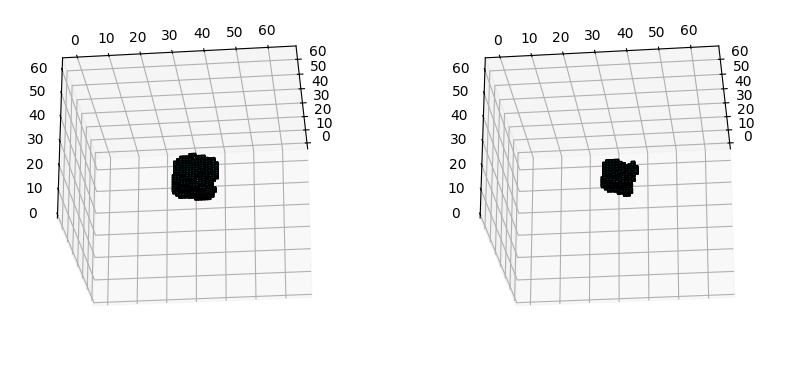

In [15]:
fig = plt.figure(figsize=(10, 20))
ax = fig.add_subplot(121, projection="3d")
ax.voxels(
    label_vol,
    edgecolor="k",
    facecolors="cyan",
    alpha=0.5,
)
# ax.voxels(vessel[40:80,40:80,40:80], edgecolor='k', facecolors='red', alpha=0.5);
ax2 = fig.add_subplot(122, projection="3d")
ax2.voxels(
    deformed_label,
    edgecolor="k",
    facecolors="cyan",
    alpha=0.5,
)
# ax2.voxels(deformed_vessel[40:80,40:80,40:80], edgecolor='k', facecolors='red', alpha=0.5);

# rotate plot

ax.view_init(-25, 6)
ax2.view_init(-25, 6)

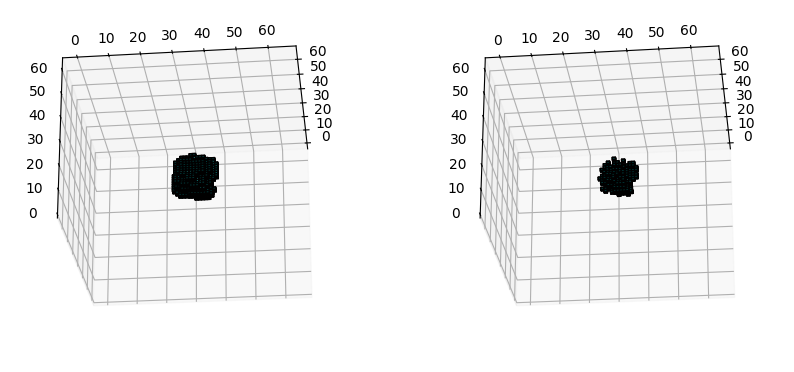

In [40]:
fig = plt.figure(figsize=(10, 20))
ax = fig.add_subplot(121, projection="3d")
ax.voxels(
    label_vol,
    edgecolor="k",
    facecolors="cyan",
    alpha=0.5,
)
# ax.voxels(vessel[40:80,40:80,40:80], edgecolor='k', facecolors='red', alpha=0.5);
ax2 = fig.add_subplot(122, projection="3d")
ax2.voxels(
    deformed_label,
    edgecolor="k",
    facecolors="cyan",
    alpha=0.5,
)
# ax2.voxels(deformed_vessel[40:80,40:80,40:80], edgecolor='k', facecolors='red', alpha=0.5);

# rotate plot

ax.view_init(-25, 6)
ax2.view_init(-25, 6)

In [118]:
# save as sitk image

deformed_label_sitk = sitk.GetImageFromArray(deformed_label)
deformed_volume_sitk = sitk.GetImageFromArray(deformed_source)
# write both

sitk.WriteImage(deformed_label_sitk, f"./odeformed_label.nii.gz")
sitk.WriteImage(deformed_volume_sitk, f"./odeformed_volume.nii.gz")

In [117]:
og_label_sitk = sitk.GetImageFromArray(label_vol)
og_volume_sitk = sitk.GetImageFromArray(source)
sitk.WriteImage(og_label_sitk, f"./oog_label.nii.gz")
sitk.WriteImage(og_volume_sitk, f"./oog_volume.nii.gz")

In [ ]:
def draw_3d_sphere(image, center, radius):
    zz, yy, xx = np.ogrid[: image.shape[0], : image.shape[1], : image.shape[2]]
    distance = (zz - center[0]) ** 2 + (yy - center[1]) ** 2 + (xx - center[2]) ** 2
    mask = distance <= radius**2
    image[mask] = 1
    return image


x = draw_3d_sphere(x, center=[55, 55, 55], radius=5)

vessel = np.zeros([128, 128, 128])
vessel[58:63, 38:73, 58:63] = 1


# get center with skimage
labels = measure.label(x)
feats = measure.regionprops(labels)

for i, obj in enumerate(feats):
    feat = feats[i]
    label_vol = labels == (i + 1)
    break

surface_points = measure.marching_cubes(label_vol, spacing=[1, 1, 1])[0]
# randomly and uniformly select 10% of the points

num_points = int(len(surface_points) * 0.2)
indices = np.random.choice(len(surface_points), num_points, replace=False)
surface_points = surface_points[indices]


# apply dilation with a ball of radius 3

radius = 3 * 2 + 1
selem = np.ones((radius, radius, radius), dtype=bool)

label_vol_dilated = morphology.binary_dilation(label_vol, footprint=selem)
surface_points_dilated = measure.marching_cubes(label_vol_dilated, spacing=[1, 1, 1])[
    0
].astype(int)
# randomly and uniformly select 10% of the points from the dilated surface
num_points_dilated = int(len(surface_points_dilated) * 0.2)
indices = np.random.choice(
    len(surface_points_dilated), num_points_dilated, replace=False
)
surface_points_dilated = surface_points_dilated[indices]


# random array in the shape of surface_points
amp = [3, 3, 3]

# dz = amp[0]*2*(np.random.rand(len(surface_points)) - 0.5)
# dy = amp[1]*2*(np.random.rand(len(surface_points)) - 0.5)
# dx = amp[2]*2*(np.random.rand(len(surface_points)) - 0.5)

# random gaussian with mean 0 and std 1
dz = amp[2] * np.random.normal(0.5, 0.1, len(surface_points))
dy = amp[1] * np.random.normal(0.5, 0.1, len(surface_points))
dx = amp[0] * np.random.normal(0.5, 0.1, len(surface_points))


# do not move points that are in the vessel
for i in range(len(surface_points)):
    p = surface_points[i].astype(int)
    if vessel[tuple(p)] == 1:
        dz[i] = 0
        dy[i] = 0
        dx[i] = 0

# dz = amp[2]*(np.random.rand(len(surface_points)))
# dy = amp[1]*(np.random.rand(len(surface_points)))
# dx = amp[0]*(np.random.rand(len(surface_points)))

center = np.array(feat.centroid)

In [ ]:
sign = ((surface_points > center).astype(int)) * 2 - 1
dz = sign[:, 2] * dz
dy = sign[:, 1] * dy
dx = sign[:, 0] * dx
surface_points_change = surface_points + np.stack([dx, dy, dz], axis=1)
points = np.concatenate(
    [surface_points, surface_points_dilated, center.reshape(-1, 3)], axis=0
)
points_target = np.concatenate(
    [surface_points_change, surface_points_dilated, center.reshape(-1, 3)], axis=0
)

In [ ]:
dim = 3
thin_plate_spline = itk.ThinPlateSplineKernelTransform[itk.D, dim].New()


points = points.astype(np.float64)
source_landmarks = thin_plate_spline.GetSourceLandmarks()
source_landmarks.SetPoints(itk.vector_container_from_array(points.flatten()))

points_target = points_target.astype(np.float64)
target_landmarks = thin_plate_spline.GetTargetLandmarks()
target_landmarks.SetPoints(itk.vector_container_from_array(points_target.flatten()))


thin_plate_spline.ComputeWMatrix()

# use x as input_image but transform to itk first

input_image = itk.image_from_array(x, is_vector=False)

deformed_image = itk.resample_image_filter(
    input_image,
    use_reference_image=True,
    reference_image=input_image,
    transform=thin_plate_spline,
)
deformed_image = itk.array_from_image(deformed_image)

# input_real_img = itk.image_from_array(real_img, is_vector=False)
# deformed_real_img = itk.resample_image_filter(
#     input_real_img,
#     use_reference_image=True,
#     reference_image=input_real_img,
#     transform=thin_plate_spline,
# )

In [ ]:
contour_deformed = measure.marching_cubes(
    deformed_image, level=0.5, spacing=[1, 1, 1], step_size=1
)[0]

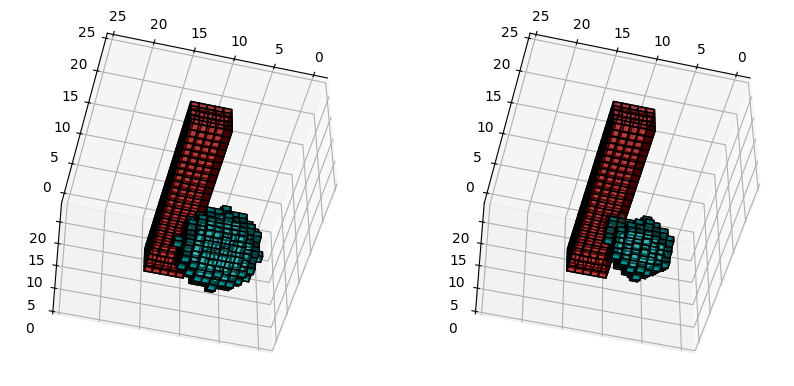

In [ ]:
fig = plt.figure(figsize=(10, 20))
ax = fig.add_subplot(121, projection="3d")
ax.voxels(x[48:72, 48:72, 48:72], edgecolor="k", facecolors="cyan", alpha=0.5)
ax.voxels(vessel[48:72, 48:72, 48:72], edgecolor="k", facecolors="red", alpha=0.5)
ax2 = fig.add_subplot(122, projection="3d")
ax2.voxels(
    deformed_image[48:72, 48:72, 48:72], edgecolor="k", facecolors="cyan", alpha=0.5
)
ax2.voxels(vessel[48:72, 48:72, 48:72], edgecolor="k", facecolors="red", alpha=0.5)

# rotate plot

ax.view_init(-50, 76)
ax2.view_init(-50, 76)

(array([[260, 260],
        [260, 275],
        [260, 290],
        [275, 260],
        [275, 275],
        [275, 290],
        [290, 260],
        [290, 275],
        [290, 290],
        [200, 200],
        [200, 350],
        [350, 200],
        [350, 350]]),
 array([[ 43.12503671, -47.17218632],
        [-23.18467843, -45.73157859],
        [ 48.84765087, -35.69426593],
        [-11.43750584,  24.98668014],
        [  0.        ,   0.        ],
        [ -1.82336825,  26.27115282],
        [-16.95299423,  12.88212033],
        [-38.40982055, -12.59336937],
        [ 38.8919657 ,  43.08542764],
        [  0.        ,   0.        ],
        [  0.        ,   0.        ],
        [  0.        ,   0.        ],
        [  0.        ,   0.        ]]))

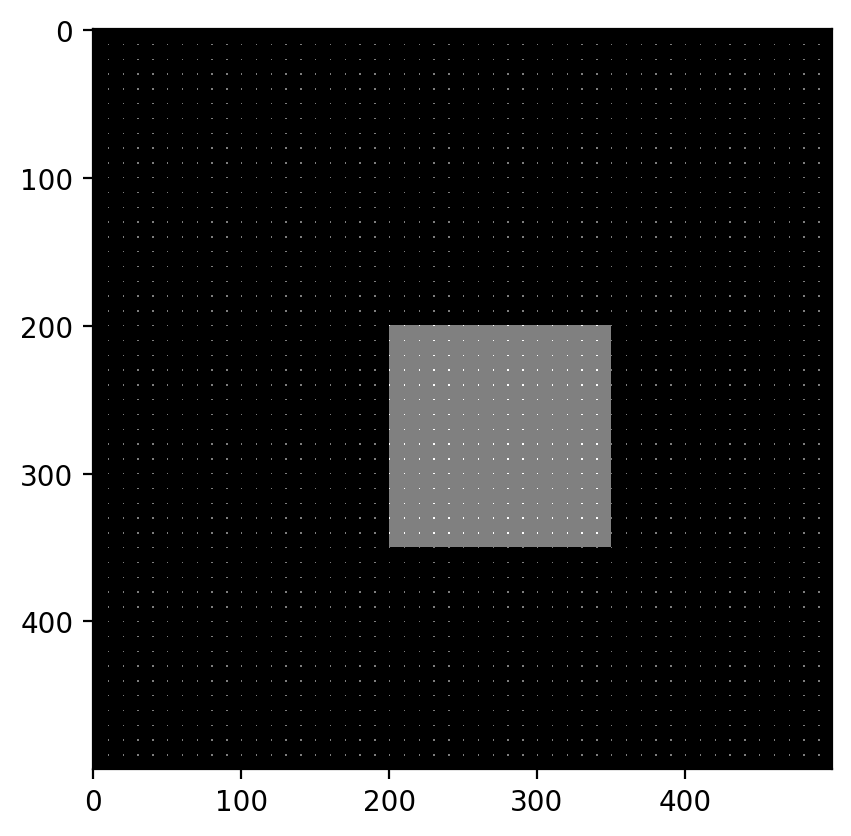

In [ ]:
x = np.zeros([500, 500], dtype=np.float32)

x[200:350, 200:350] = 1.0

fig = plt.figure(dpi=200)
plt.imshow(x, cmap="gray", interpolation="nearest")

real_img = plt.imread("./aaa.jpg")
real_img = np.zeros_like(x)
real_img[::10, ::10] = 1
# reszie to 500x500
# real_img = transform.resize(real_img, (500, 500), anti_aliasing=True)

# real_img = real_img[:,:,0]
plt.imshow(real_img, cmap="gray", interpolation="nearest", alpha=0.5)
bounding_box_coords = [200, 200], [350, 350]


amp = [50, 50]


# dx=amp[0]*2*(np.random.random_sample((3,3,3))-0.5)
# dy=amp[1]*2*(np.random.random_sample((3,3,3))-0.5)
# dz=amp[2]*2*(np.random.random_sample((3,3,3))-0.5)
# dx[1,1,1]=dy[1,1,1]=dz[1,1,1]=0

dx = amp[0] * 2 * (np.random.random_sample((3, 3)) - 0.5)
dy = amp[1] * 2 * (np.random.random_sample((3, 3)) - 0.5)


dx[1, 1] = dy[1, 1] = dz[1, 1] = 0


center_point = [275, 275]

factor = 15
factor_2 = 5

points_x = np.arange(275 - factor, 275 + factor + 1, factor)
points_y = np.arange(275 - factor, 275 + factor + 1, factor)


center = 275
points = np.array(np.meshgrid(points_x, points_y)).T.reshape(-1, 2)

additional_points_x = [
    center - factor * factor_2,
    center - factor * factor_2,
    center + factor * factor_2,
    center + factor * factor_2,
]
additional_points_y = [
    center - factor * factor_2,
    center + factor * factor_2,
    center - factor * factor_2,
    center + factor * factor_2,
]


points = np.concatenate(
    (points, np.array([additional_points_x, additional_points_y]).T.reshape(-1, 2))
)
disp = np.array([dx, dy]).T.reshape(-1, 2)
additional_points_dx = [0, 0, 0, 0]
additional_points_dy = [0, 0, 0, 0]

disp = np.concatenate(
    (disp, np.array([additional_points_dx, additional_points_dy]).T.reshape(-1, 2))
)


points_target = points + disp

points, disp

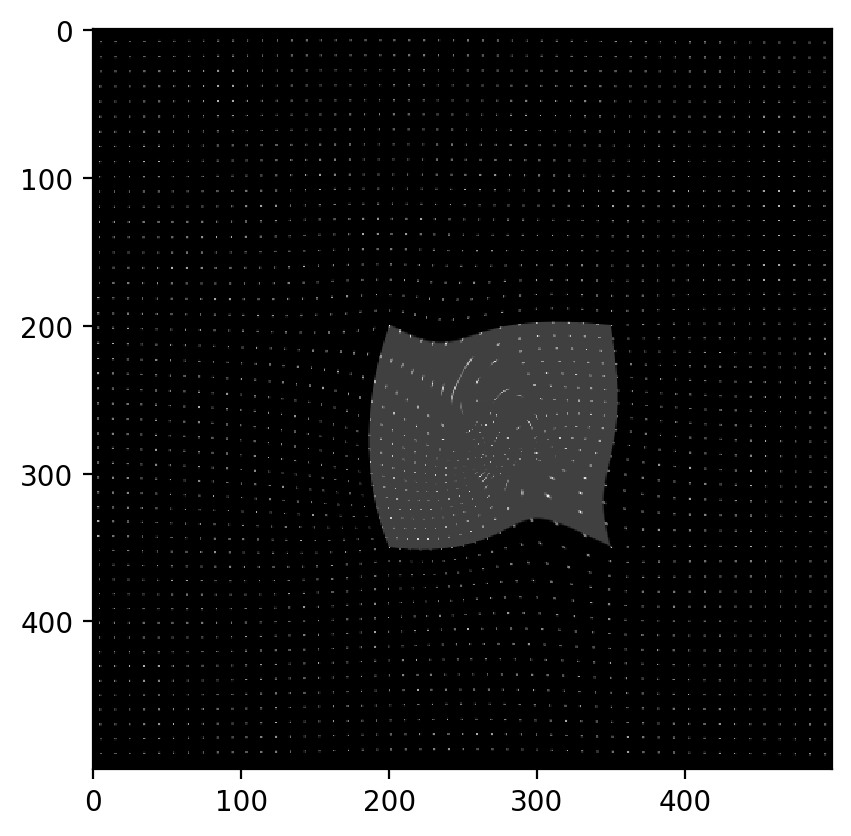

In [ ]:
x_deformed = itk.array_from_image(deformed_image)

fig = plt.figure(dpi=200)
plt.imshow(x_deformed, cmap="gray", interpolation="nearest")
plt.imshow(deformed_real_img, cmap="gray", interpolation="nearest", alpha=0.75)

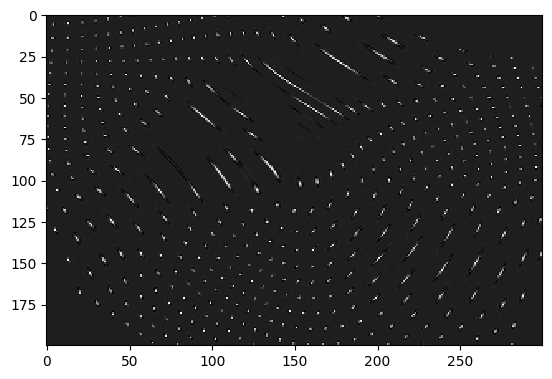

In [ ]:
import elasticdeform

X = np.zeros((200, 300))
X[::10, ::10] = 1

# apply deformation with a random 3 x 3 grid
X_deformed = elasticdeform.deform_random_grid(X, sigma=25, points=3)

plt.imshow(X_deformed, cmap="gray", interpolation="nearest")